# Transfer Learning & Visualizations


#### Transfer learning TL:
Instead of training a CNN from scratch, you take a pretrained model that already learned useful visual features from a huge dataset like ImageNet.  

Example:  
A CNN trained on ImageNet already knows:  
- edges  
- corners
- textures
- fur
- wheels
- faces
- generic object structure
**So you do not want to retrain all that from zero**  
> You keep the pretrained CNN part and only replace the final classifier layer with a new one adapted to your problem.  

Example:  
Original model: $\text{CNN features} \rightarrow \text{classifier for 1000 ImageNet classes}$  

New model: $\text{same CNN features} \rightarrow \text{new classifier for your classes}$  
So if your new task has only 2 classes, you replace the final layer with an output of size 2.  


#### Advantages of transfer learning:
1.	Computational cost  
Training a big CNN from scratch is slow and expensive as hell.  
Transfer learning is much faster because most weights are already good.  

2.	Dataset size  
If your dataset is small, training from scratch is risky because the model overfits immediately.  
Transfer learning helps because the model already has general visual knowledge.  

3.	Generalization  
A pretrained model tends to generalize better because it has already seen millions of images.  

Example:  
A model trained to recognize dogs may already know:  
- fur
- paws
- eyes
- ears
So later it can more easily learn cats because cats share many features with dogs.  ￼


#### Code implementation

import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
...
N_CLASSES = 2
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features=in_features, out_features=N_CLASSES)


> from torchvision.models import resnet18, ResNet18_Weights  
Imports the ResNet18 architecture and pretrained weights.  

> N_CLASSES = 2  
Your new dataset has 2 classes.  

> model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)  
Loads ResNet18 pretrained on ImageNet.  

> in_features = model.fc.in_features  
Reads how many inputs the original final fully-connected layer receives.  
For ResNet18 this is usually 512.  

> model.fc = nn.Linear(in_features=in_features, out_features=N_CLASSES)  
Replace the old ImageNet classifier: $512 \rightarrow 1000$  
with a new one: $512 \rightarrow 2$  
So now the model outputs 2 logits instead of 1000.  


So this is kept:  
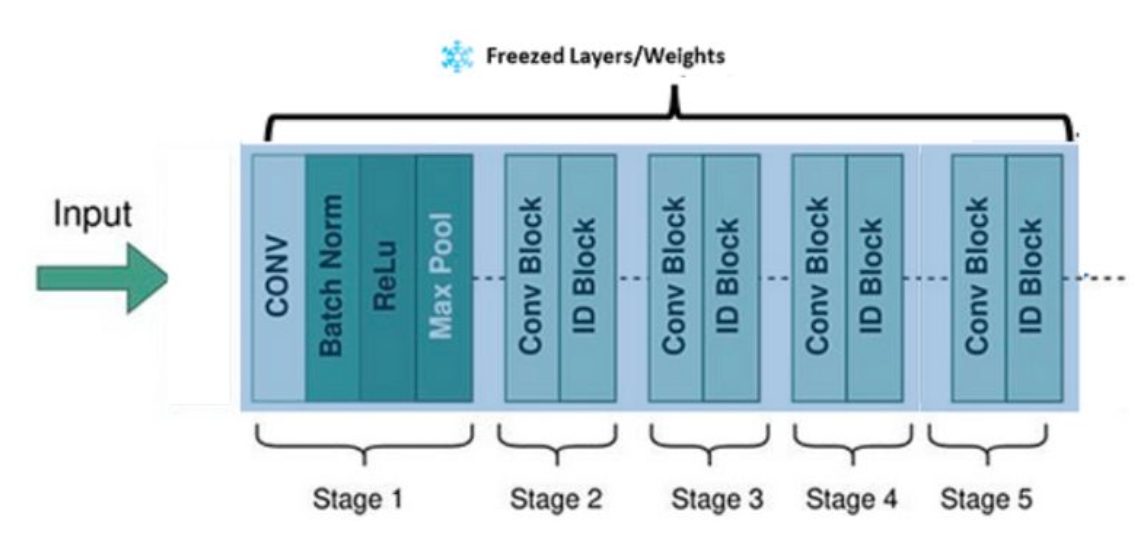

- You freeze almost all layers of ResNet.  
    - Meaning: their weights are not updated during training.
    - So:
        - convolution layers stay fixed
	    - residual blocks stay fixed
	    - pretrained features stay fixed

> You keep the AVG pooling and the flattening leyer too  
> Only the last classification layer is trained.  

> So training becomes: $\text{image} \rightarrow \text{frozen pretrained CNN} \rightarrow \text{new trainable classifier}$  

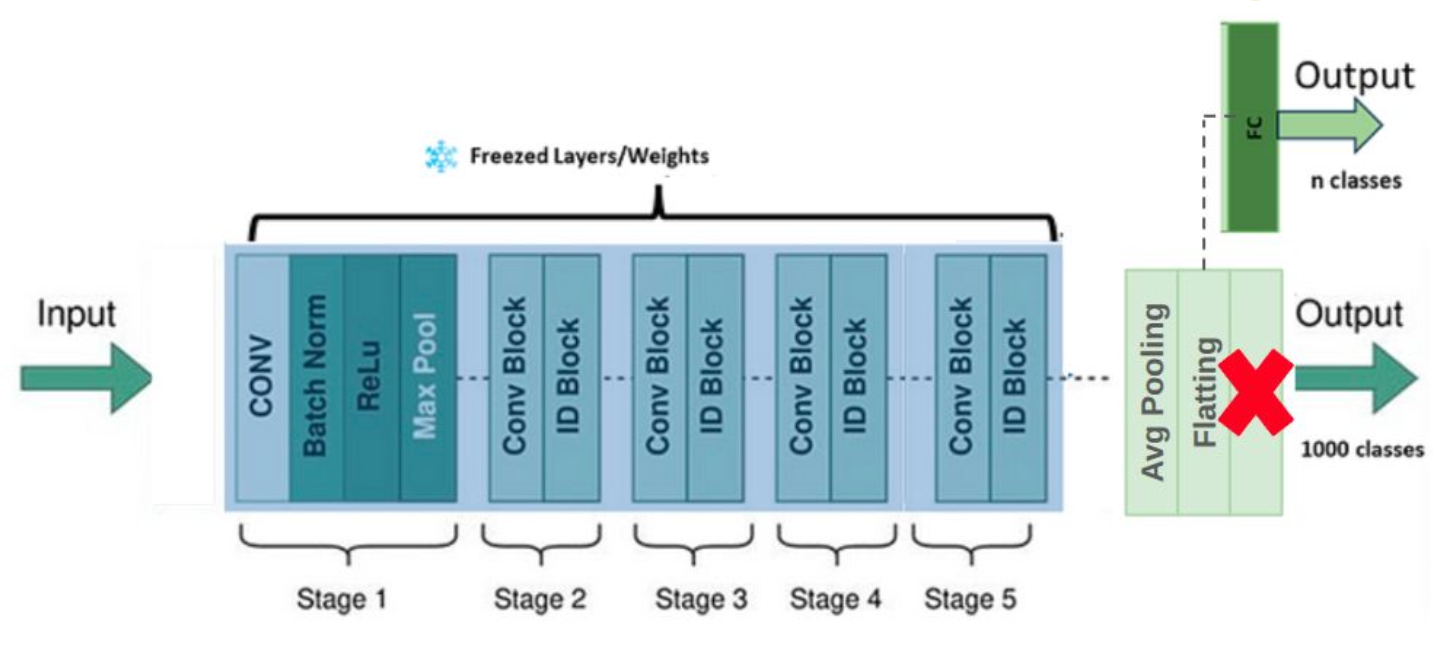

# TODO
1.	Open the Colab notebook  
2.	Download the pizza-steak-sushi dataset  
3.	Load the dataset  
4.	Load pretrained ResNet18  
5.	Replace final classifier  
6.	Freeze pretrained layers  
7.	Train only the new classifier layer  
8.	Evaluate performance  
9.	Plot training and validation loss / accuracy  

The dataset has 3 classes:
- pizza
- steak
- sushi

----

## Install missing dependencies and import libraries

In [ ]:
# Install missing dependencies
!pip install -q torchinfo torchmetrics wandb

In [ ]:
# Import required libraries/code
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchmetrics.functional.classification import multiclass_confusion_matrix
import seaborn as sns

from torch import nn
from torchvision import transforms, datasets

from torchinfo import summary

import wandb
from timeit import default_timer as timer

import os

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import pandas as pd

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

## Goal: plot a confusion matrix of the predictions on the test set

#### Install the dataset on colab

In [ ]:
!wget https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip
!mkdir -p data
!unzip -n pizza_steak_sushi.zip -d data/pizza_steak_sushi

#### Prepare data
- build transformer to apply to the input images --> let's add data augmentation
- build dataset
- build dataloader

In [ ]:
# Create a transforms pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

In [ ]:
# Create training and testing DataLoader's as well as get a list of class names
    # we feed the ImageFolder a folder path --> it will consider all the elements inside, even if there are sub-folders --> it doesn't care it takes all files

data_path = "data/pizza_steak_sushi"
train_dset = ImageFolder(f"{data_path}/train", transform=simple_transform)
test_dset = ImageFolder(f"{data_path}/test", transform=simple_transform)

class_names = list(os.listdir(f"{data_path}/train"))  # ['pizza', 'steak', 'sushi']
print(f"Class names: {class_names}")

train_dataloader = DataLoader(train_dset, batch_size=32, num_workers=2, shuffle=True)
test_dataloader = DataLoader(test_dset, batch_size=32, num_workers=2)

#### Get and prepare the pretrained model
- Create an EfficientNet-B0 model --> EfficientNet-B0 è un’architettura di rete neurale convoluzionale sviluppata da ricercatori di Google AI  
- Load pretrained weights, usually trained on ImageNet  
- Move the model to the selected device  

In [ ]:
# Setup the model with pretrained weights and move everything on the GPU
model_0 = torchvision.models.efficientnet_b0(pretrained=True).to(device)

So, model_0.features is the CNN backbone of EfficientNet-B0, it constains:
- convolutions
- batch norms
- activation layers
- feature extraction blocks
Those layers already contain pretrained ImageNet knowledge.  

If I set the gradient = False $\rightarrow$ **“Do not compute gradients for these weights.”** $\rightarrow$ THEREFORE $\rightarrow$ **“Do not update these weights during backprop.”**


In [ ]:
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in model_0.features.parameters():
    param.requires_grad = False

In [ ]:
# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the length of class_names (one output unit for each class)
output_shape = len(class_names)

> Now replace the original classifier head of EfficientNet-B0 with a new one.  

The new classifier has two layers:  
1.	**Dropout**  
2.	**Linear layer**  


> Dropout:  

The feature extraction (the CNN imported part) outputs a bunch of values  
Due to dropout 20% of those values is set to 0  

Suppose the feature extractor outputs: $x = [2,\ 5,\ 3]$  
Dropout with p=0.2 may randomly turn it into: $x = [2,\ 0,\ 3]$  

Suppose the linear layer computes: $y = w_1x_1 + w_2x_2 + w_3x_3 + b$  
Suppose at the end the learned weight matrix is: $w = [0.4,\ 0.1,\ 0.7]$

Then without dropout we would get: $y = 0.4(2) + 0.1(5) + 0.7(3)$  
So: $y = 0.8 + 0.5 + 2.1 = 3.4$  

Now suppose dropout sets: $x_2 = 0$

Then: $y = 0.4(2) + 0.1(0) + 0.7(3)$
So: $y = 0.8 + 0 + 2.1 = 2.9$

So that neuron $W_2$ contributes nothing because dropout set $x_2 = 0$. 


> Neurons = number of rows / elements in the weights matrix --> so 1 neuron = 1 row / value of the weight matrix  
> That neuron $W_2=0.1$ contributes nothing, as the weight 0.1 gets multipied by 0 --> the neuron corresponding to the weight value 0.1 gets skipped  
So by setting the input x_2 = 0 we forced x_2 to skip one neuron ... why would we do this?  
> This helps reduce overfitting.  
> Basically the model cannot rely too much on a few specific neurons, otherwise dropout randomly nukes them --> good luck idiot, use other features too.  



> Linear layer  
Create the final fully connected layer.  
For EfficientNet-B0, after the feature extractor, pooling and flattening, the model outputs a vector of size 1280.  
As a consequence we want out new linear layer to take a 1280 vector as inpit --> in_features=1280.  
And then return an output with dimensions = to the number of classes --> out_features=output_shape  

Since we have 3 classes, the linear layer becomes: $1280 \rightarrow 3$  
Meaning: the model takes the 1280 extracted features and converts them into 3 logits: $[\text{pizza score},\ \text{steak score},\ \text{sushi score}]$  

In [ ]:
model_0.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape, # same number of output units as our number of classes
                    bias=True)).to(device)

### **WE DO NOT FREEZE THIS PART, WE WANT TO COMPUTE THE GRADIENT FOR THIS PART AS WE WANT TO UPDATE IT**

---

#### Train and evaluate the model
##### Logic
- create loss
- create optimizer
- initialise wandb to keep track of the model training performance
- define number of epochs

> **train**  
- iterate over epochs:
    - iterate over batches:
        - move data and label to GPU

        - optmizer.zero_grad()
        - predct label with forward pass
        - compute loss
        - compute loss gradient with backpropagation (backward)
        - update the model weights with optimizer.step()

        - keep track of running loss + accuracy --> print epoch loss and epoch accuracy

    

> **evaluate**
- iterate over epochs:
    - iterate over batches:
        - no gradient update --> with torch.no_grad()
        - move data and labels to GPU

        - predict label with forward pass
        - compute loss

        - keep track of running loss + accuracy --> print epoch loss and epoch accuracy


##### Implementation
> When implementing its tidier and cleaner to:  

- iterate over epochs
    - **train:**
        - iterate over batches
            - move data and label to GPU

            - optmizer.zero_grad()
            - predct label with forward pass
            - compute loss
            - compute loss gradient with backpropagation (backward)
            - update the model weights with optimizer.step()

            - keep track of running loss + accuracy --> print epoch loss and epoch accuracy


    - **evaluate:**
        - iterate over batches:
            - move data and label to GPU

            - optmizer.zero_grad()
            - predct label with forward pass
            - compute loss
            - compute loss gradient with backpropagation (backward)
            - update the model weights with optimizer.step()

            - keep track of running loss + accuracy --> print epoch loss and epoch accuracy


In [ ]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=1e-3)

# wandb init
wandb.init(
    project="lab5-transfer-learning",
    config={
        "architecture": "EfficientNet-B0",
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "loss_fn": "CrossEntropyLoss",
        "epochs": 10
    }
)

num_epochs = 10

In [ ]:
def train(model, optimizer, dataloader, loss_fn, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X, y in dataloader:
        X = X.to(device)
        y = y.to(device)

        # forward
        y_logits = model(X)
        loss = loss_fn(y_logits, y)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # stats
        running_loss += loss.item()
        y_pred = torch.argmax(y_logits, dim=1)
        correct += (y_pred == y).sum().item()
        total += y.size(0)

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc





def test(model, dataloader, loss_fn, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)

            y_logits = model(X)
            loss = loss_fn(y_logits, y)

            running_loss += loss.item()
            y_pred = torch.argmax(y_logits, dim=1)
            correct += (y_pred == y).sum().item()
            total += y.size(0)

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
# Start timer
start_time = timer()


for epoch in range(num_epochs):
    train_loss, train_acc = train(
        model=model_0,
        optimizer=optimizer,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        device=device
    )

    test_loss, test_acc = test(
        model=model_0,
        dataloader=test_dataloader,
        loss_fn=loss_fn,
        device=device
    )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | "
        f"test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}"
    )

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc
    })

# End timer
end_time = timer()
total_time = end_time - start_time

print(f"[INFO] Total training time: {total_time:.3f} seconds")
wandb.log({"total_training_time_sec": total_time})

wandb.finish()

---

### Make a confusion matrix with the test preds and the truth labels

HINT: Look at the torchmetrics.functional.classification.multiclass_confusion_matrix from the torchmetrics library

- First collect all predictions and true labels in lists --> use the final already trained model to predict the classes.
- Convert the list with the predictions and the lists of the actual labels into tensors
- Compute the confusion matrix
- Then visualise it

In [ ]:
# collect all predictions and true labels
model_0.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_dataloader:
        X = X.to(device)
        y = y.to(device)

        logits = model_0(X)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())

In [ ]:
# concatenate everything into a single tensor
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

In [ ]:
# compute confusion matrix
num_classes = 3

confmat = multiclass_confusion_matrix(
    preds=all_preds,
    target=all_labels,
    num_classes=num_classes
)


In [ ]:
# visualize a heatmap

class_names = ["pizza", "steak", "sushi"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    confmat.numpy(),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

----

## Step 3: Get the "most wrong" of the predictions on the test dataset and plot the 5 "most wrong" images. You can do this by:
* Predicting across all of the test dataset, storing the labels and predicted probabilities.
* Sort the predictions by *wrong prediction* and then *descending predicted probabilities*, this will give you the wrong predictions with the *highest* prediction probabilities, in other words, the "most wrong" --> the model was confident the image belonged to a certain class and it did not.
* Plot the top 5 "most wrong" images, why do you think the model got these wrong?

So the **workflow** is:
1.	run the trained model on the whole test set  
2.	keep, for each sample:  
- image tensor
- true label
- predicted label
- predicted probability
- whether prediction is correct

3.	filter wrong predictions  
4.	sort them by predicted probability descending  
5.	plot the top 5  


#### Implementation logic
Iterate over each batch of the dataloader, considering the batch of images and their respective labels.  
Example: a batch may contain 64 input images and their 64 true labels.  

For all the images in the batch, predict their labels using the model.  
For each image, since we have 3 classes, the model predicts 3 values, so the returned tensor has shape: [64, 3]  

Conceptually, it looks like:  

$\begin{bmatrix} \text{pred1\_im1} & \text{pred2\_im1} & \text{pred3\_im1} \\ \text{pred1\_im2} & \text{pred2\_im2} & \text{pred3\_im2} \\ \text{pred1\_im3} & \text{pred2\_im3} & \text{pred3\_im3} \\ \vdots & \vdots & \vdots \\ \text{pred1\_im64} & \text{pred2\_im64} & \text{pred3\_im64} \end{bmatrix}$


Each row corresponds to one image, and the 3 values in that row are the logits for the 3 classes.  
Then, for each row, so for each image, convert the 3 logits into probabilities using softmax along dim=1  

With the same reasoning, compute:  
- the most probable class using argmax(dim=1)
- the highest predicted probability for each image, meaning the probability associated with the predicted class

So while iterating over the batches, for each batch we compute:
- a tensor containing the predicted class for each image in the batch
- a tensor containing the predicted probability of that predicted class for each image in the batch


The lab asks to:
* Create a DataFrame with sample, label, prediction, pred prob
* Sort DataFrame by correct (does label == prediction)
* Sort DataFrame by pred prob (descending)
* Plot the top 5 "most wrong" image predictions

In [ ]:
model_0.eval()

test_pred_records = []

with torch.no_grad():
    for X, y in test_dataloader:
        X = X.to(device)
        y = y.to(device)

        # in each batch there are N (example N = 64) images and their respective label
            # --> X = [image 1, ..., image 64] ; y = [true label 1, ..., true label 64]
        
        # compute logits, the NN computes 3 values for each image, so 1 image = 3 values
            # so logits will be a 2D tensor:
            # [
            #   [logits1 image1, logits2 image1, logits2 image1],
            #   [logits1 image2, logits2 image2, logits2 image2],
            # ...
            #   [logits1 image64, logits2 image64, logits2 image64]
            # ]
        
        # convert them into probabilities with softmax:
        # [
            #   [prob1 image1, prob2 image1, prob2 image1],
            #   [prob1 image2, prob2 image2, prob2 image2],
            # ...
            #   [prob1 image64, prob2 image64, prob2 image64]
        # ]

        # argmax dim = 1 --> for each row pick the position of the highest value --> pick predicted class
        # pick the value of the highest probability --> max

        logits = model_0(X)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        pred_probs = torch.max(probs, dim=1).values

        # preds = [predicted class im1, ..., predicted class im64]
        # pred_probs = [predicted probability im1, ..., predicted probability im64]



        # iterate over every single image and label in one single batch
        # save the single image
        # save the respective true label
        # save the respective previously computed predicted class and probability
        # check if the predicted class == true class --> if yes "correct" : True

        for i in range(len(X)):
            
            # is_correct = True if predicted label = true label, False otherwise
            is_correct = (preds[i].cpu().item() == y[i].cpu().item())
            
            test_pred_records.append({
                "image": X[i].cpu(),
                "label": y[i].cpu().item(),
                "pred": preds[i].cpu().item(),
                "pred_prob": pred_probs[i].cpu().item(),
                "correct": is_correct
            })


# we can create a dataframe from a list of dictionaries, each dictionary = row and they all have same keys = columns
# filter only wrong predictions
# sort by prediction confidence, descending --> keep only wrong predictions where the NN was confifdent to predict the true class

pred_df = pd.DataFrame(test_pred_records)

most_wrong_df = pred_df[pred_df["correct"] == False].copy()

most_wrong_df = most_wrong_df.sort_values("pred_prob", ascending=False)


# inspect
most_wrong_df.head()


---

## Step 4: Train the model from section 4 above with more data, say 20% of the images from Food101 of Pizza, Steak and Sushi images.
* You can find the [20% Pizza, Steak, Sushi dataset](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip) on the course GitHub. It was created with the notebook [`extras/04_custom_data_creation.ipynb`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb).


> **Everything is the same as we did before, it only uses a different DS --> basically a recap**

### Get 20% data

In [ ]:
!wget https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip
!mkdir -p data
!unzip pizza_steak_sushi_20_percent.zip -d data/pizza_steak_sushi_20_percent

# Build data transformer, data sets and data loaders
- Same as before, but using a different dataset, we don't use the previous one
> - **The new dataset has ONLY 20% of the total data in the previous dataset**

In [ ]:
# Create a transforms pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

In [ ]:
# Create training and testing DataLoader's as well as get a list of class names

data_path = "data/pizza_steak_sushi_20_percent"
train_dset_20p= ImageFolder(f"{data_path}/train", transform=simple_transform)
test_dset_20p = ImageFolder(f"{data_path}/test", transform=simple_transform)
class_names = list(os.listdir(f"{data_path}/train"))  # 'pizza', 'steak', 'sushi'
print(f"Class names: {class_names}")


train_dataloader_20p = DataLoader(train_dset_20p, batch_size=32, num_workers=2, shuffle=True)
test_dataloader_20p = DataLoader(test_dset_20p, batch_size=32, num_workers=2)

# train_dataloader, test_dataloader, class_names

## Get a pretrained model
- load pretrained model
- freeze the feature extractor part of the model
- replace the classifier

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained EfficientNet-B0
model_20p = torchvision.models.efficientnet_b0(pretrained=True).to(device)

In [ ]:
# Freeze feature extractor
for param in model_20p.features.parameters():
    param.requires_grad = False

In [ ]:
# Replace classifier
output_shape = len(class_names)

model_20p.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=output_shape, bias=True)
).to(device)

In [ ]:
loss_fn = nn.CrossEntropyLoss()

# Train only classifier parameters
optimizer = torch.optim.Adam(model_20p.classifier.parameters(), lr=1e-3)

In [ ]:
def train(model, optimizer, dataloader, loss_fn, device):
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        y_logits = model(X)
        loss = loss_fn(y_logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(y_logits, dim=1)
        train_correct += (preds == y).sum().item()
        train_total += y.size(0)

    train_loss /= len(dataloader)
    train_acc = train_correct / train_total

    return train_loss, train_acc


def test(model, dataloader, loss_fn, device):
    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            y_logits = model(X)
            loss = loss_fn(y_logits, y)

            test_loss += loss.item()
            preds = torch.argmax(y_logits, dim=1)
            test_correct += (preds == y).sum().item()
            test_total += y.size(0)

    test_loss /= len(dataloader)
    test_acc = test_correct / test_total

    return test_loss, test_acc

## Train a model with 20% of the data 

In [ ]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

num_epochs = 10

wandb.init(
    project="lab5-transfer-learning",
    name="efficientnet_b0_pizza_steak_sushi_20p",
    config={
        "architecture": "EfficientNet-B0",
        "pretrained": True,
        "frozen_features": True,
        "dataset": "pizza_steak_sushi_20_percent",
        "epochs": num_epochs,
        "batch_size": 32,
        "learning_rate": 1e-3,
        "optimizer": "Adam"
    }
)

start_time = timer()

for epoch in range(num_epochs):
    train_loss, train_acc = train(
        model=model_20p,
        optimizer=optimizer,
        dataloader=train_dataloader_20p,
        loss_fn=loss_fn,
        device=device
    )

    test_loss, test_acc = test(
        model=model_20p,
        dataloader=test_dataloader_20p,
        loss_fn=loss_fn,
        device=device
    )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss: {train_loss:.4f} | "
        f"train_acc: {train_acc:.4f} | "
        f"test_loss: {test_loss:.4f} | "
        f"test_acc: {test_acc:.4f}"
    )

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc
    })

end_time = timer()
print(f"[INFO] Total training time: {end_time - start_time:.3f} seconds")

wandb.log({"total_training_time_sec": end_time - start_time})
wandb.finish()

---

## Step 5: Try a different model from [`torchvision.models`](https://pytorch.org/vision/stable/models.html) on the Pizza, Steak, Sushi data, how does this model perform?
* You'll have to change the size of the classifier layer (input, the in_features) to suit our problem.
* You may want to try an EfficientNet with a higher number than our B0, perhaps `torchvision.models.efficientnet_b2()`?
  * **Note:** Depending on the model you use you will have to prepare/transform the data in a certain way.

In [ ]:
#TODO